In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json

In [2]:
path = Path('..//..//results//15062026//nn_inputs')

acc = np.load(Path(path, 'acc_inputs.npy'))

strain = np.load(Path(path, 'strain_inputs.npy'))

temp = np.load(Path(path, 'temperature_inputs.npy'))

event_ids = np.load(Path(path, 'event_ids.npy'))


In [6]:
with open(f'{path}//metadata//sensor_ids.json') as f:
    sensor_names = json.load(f)

In [9]:
sensor_names['acc_z']

['NEW_S1_DO_INT_ACC_Z',
 'NEW_S1_DO_MID_ACC_Z',
 'NEW_S1_UP_INT_ACC_Z',
 'NEW_S1_UP_MID_ACC_Z',
 'NEW_S2_DO_INT_ACC_Z',
 'NEW_S2_DO_MID_ACC_Z',
 'NEW_S2_UP_INT_ACC_Z',
 'NEW_S2_UP_MID_ACC_Z']

In [ ]:
#Wanting to get familiar with the data, first of all
#Making a simple statistical baseline for strain and accelerometer data
#to see whether the data changes over time

#Just taking mu = SET1.mean, sigma = SET1.std and computing the z-score for each run separately
#Doing this for each sensor (40 sensors) + each strain/accelerometer


(12107,)

### Evaluation of data properties

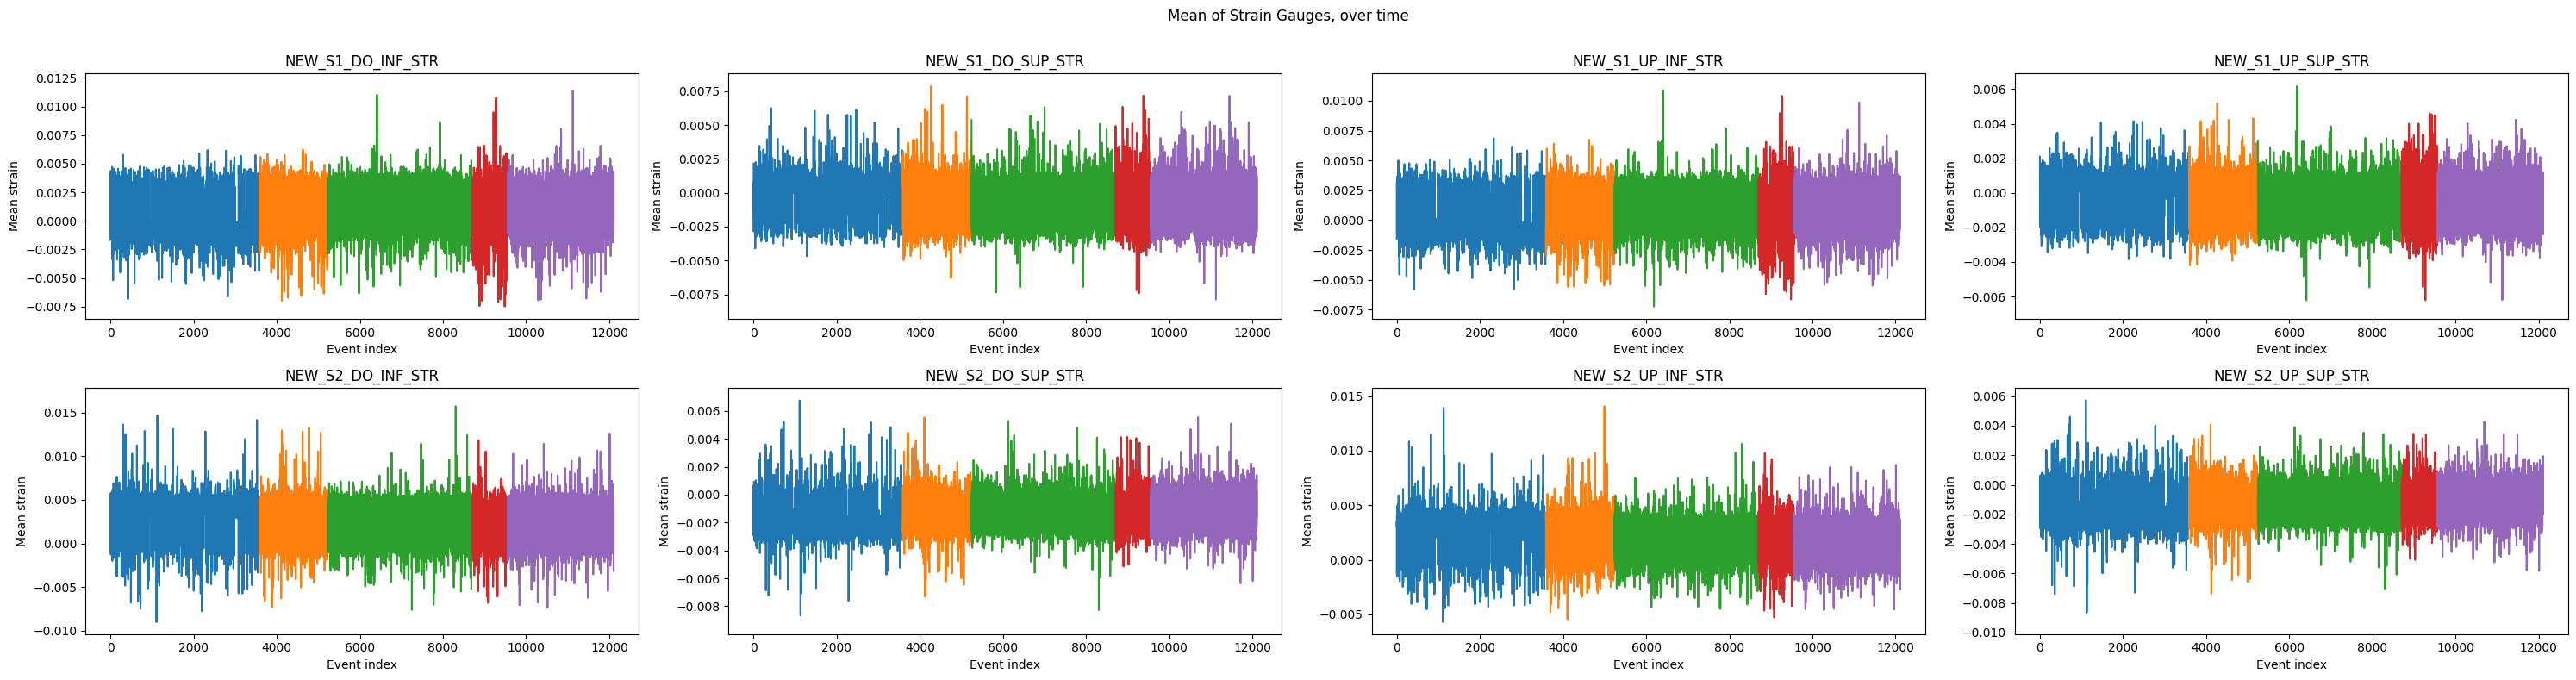

In [79]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

z_alpha = 1.96

plt.figure(figsize = (30,8))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = strain[set_mask]

    set_mean = np.mean(set_z, axis = 1)
    set_std = np.std(set_z, axis = 1)/np.sqrt(set_z.shape[1])


    for i in range(set_mean.shape[1]):
        plt.subplot(2,4,i+1)
        plt.plot(np.arange(idx, len(set_mean)+idx),set_mean[:,i])
        plt.fill_between(np.arange(idx, len(set_mean)+idx), set_mean[:,i] - z_alpha*abs(set_std[:,i]),set_mean[:,i] + z_alpha * abs(set_std[:,i]), alpha = 0.95)

        plt.title(sensor_names['strain'][i])
        plt.ylabel('Mean strain')
        plt.xlabel('Event index')

    idx += len(set_mean)


plt.suptitle('Mean of Strain Gauges, over time\n')
plt.tight_layout()
plt.show()


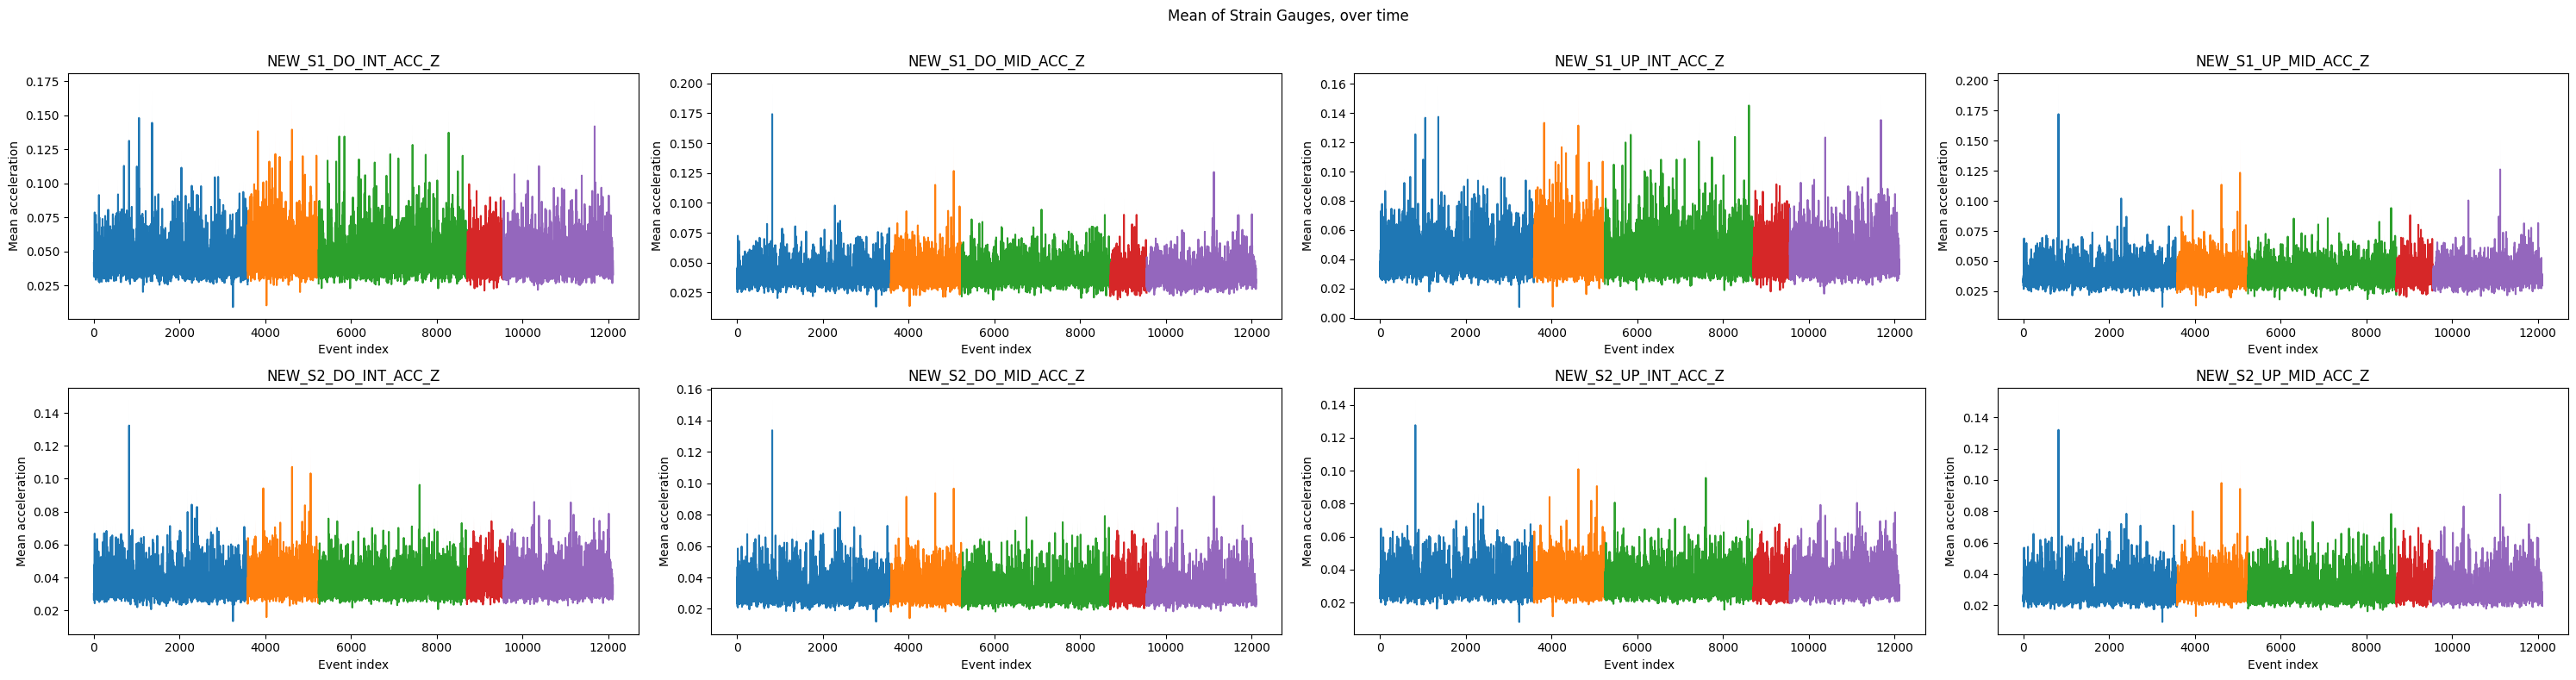

In [78]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

z_alpha = 1.96

plt.figure(figsize = (30,8))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = acc[set_mask]

    set_mean = np.mean(set_z, axis = 1)
    set_std = np.std(set_z, axis = 1)/np.sqrt(set_z.shape[1])


    for i in range(set_mean.shape[1]):
        plt.subplot(2,4,i+1)
        plt.plot(np.arange(idx, len(set_mean)+idx),set_mean[:,i])
        plt.fill_between(np.arange(idx, len(set_mean)+idx), set_mean[:,i] - z_alpha*abs(set_std[:,i]),set_mean[:,i] + z_alpha * abs(set_std[:,i]), alpha = 1)
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('Mean acceleration')
        plt.xlabel('Event index')

    idx += len(set_mean)


plt.suptitle('Mean of Strain Gauges, over time\n')
plt.tight_layout()
plt.show()


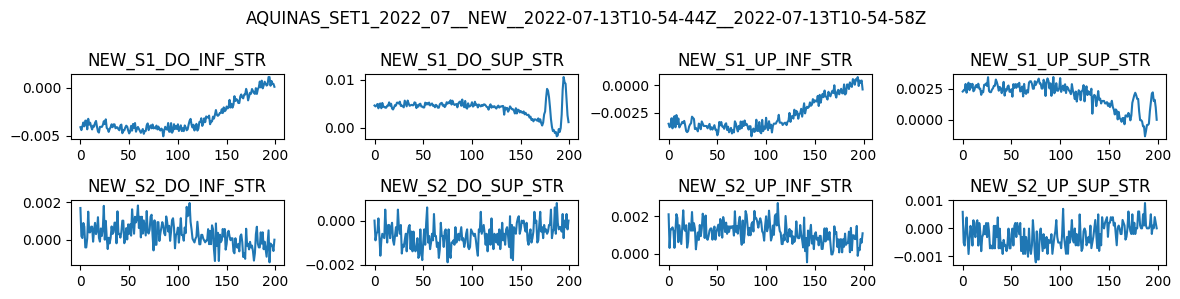

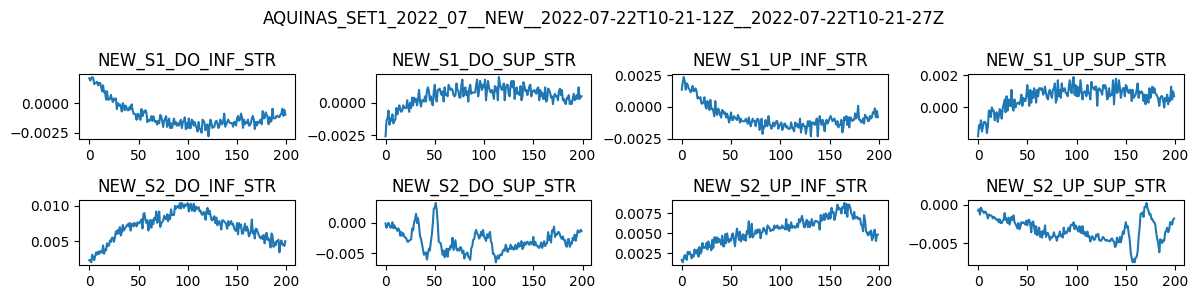

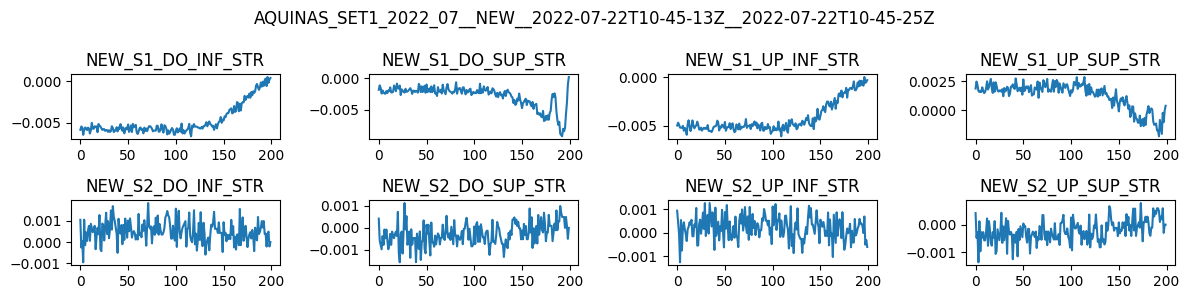

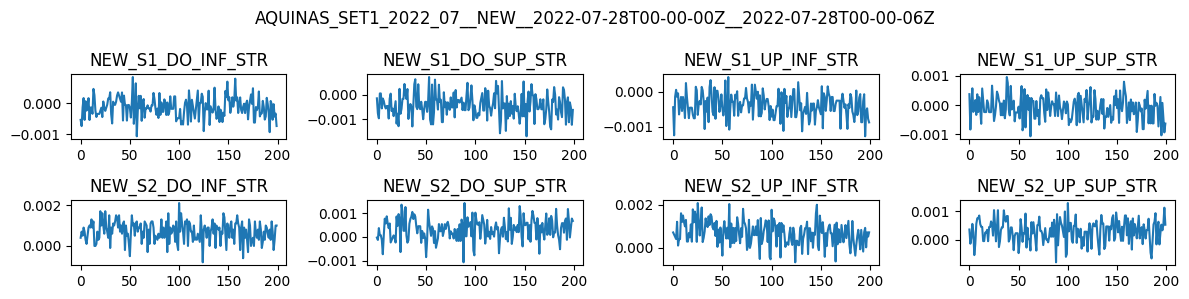

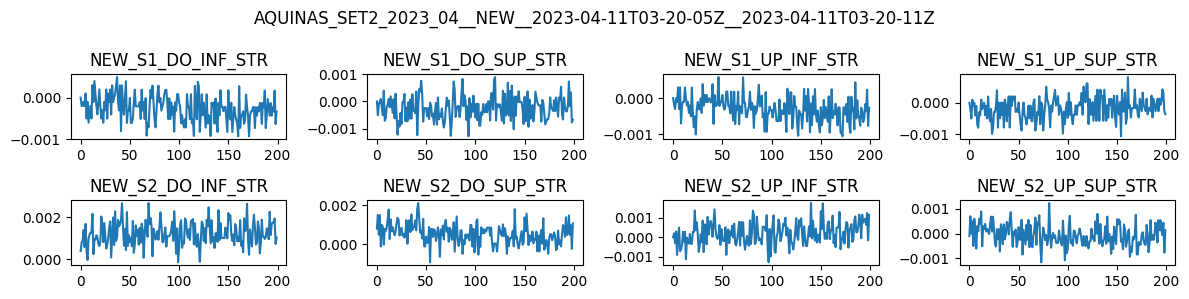

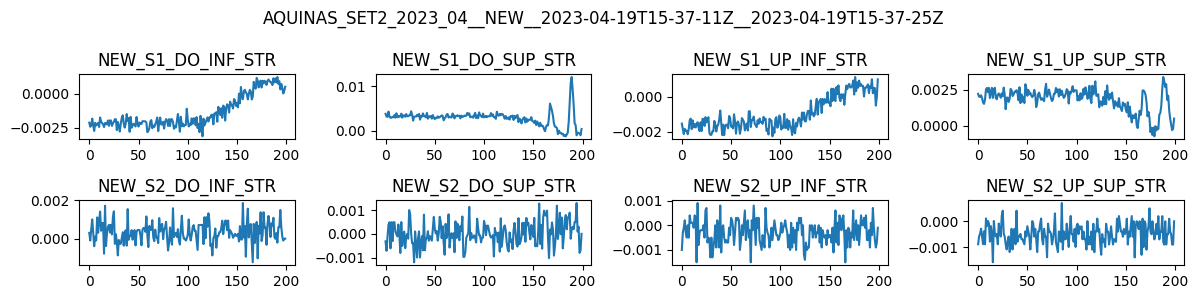

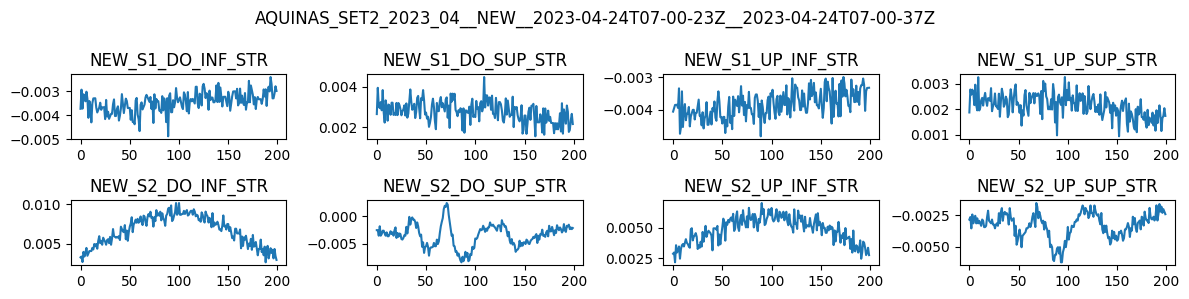

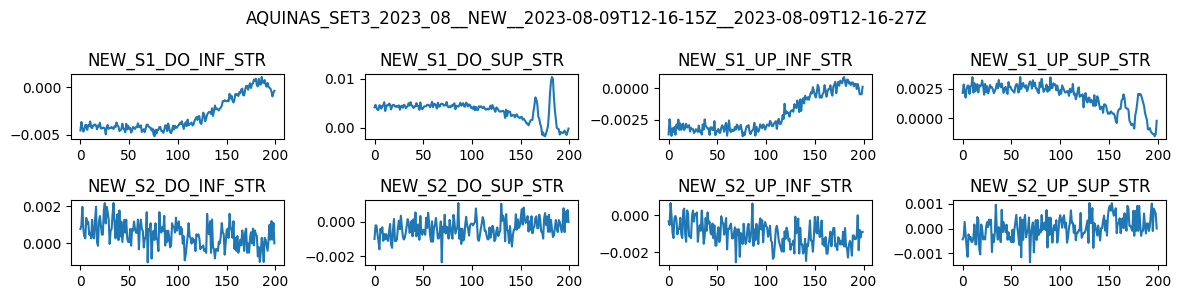

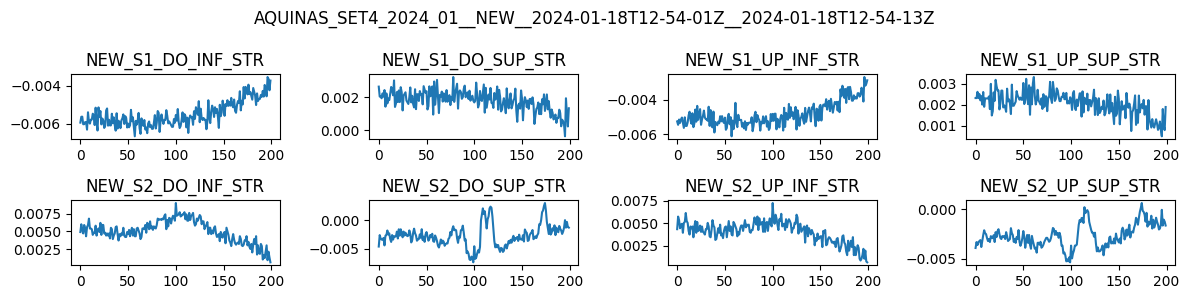

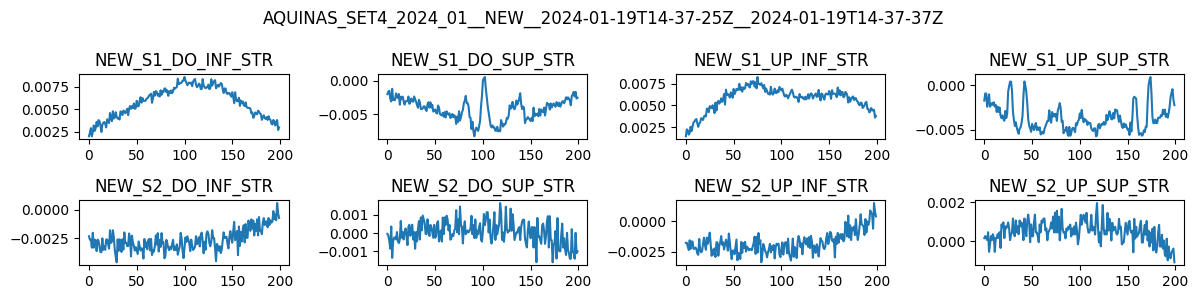

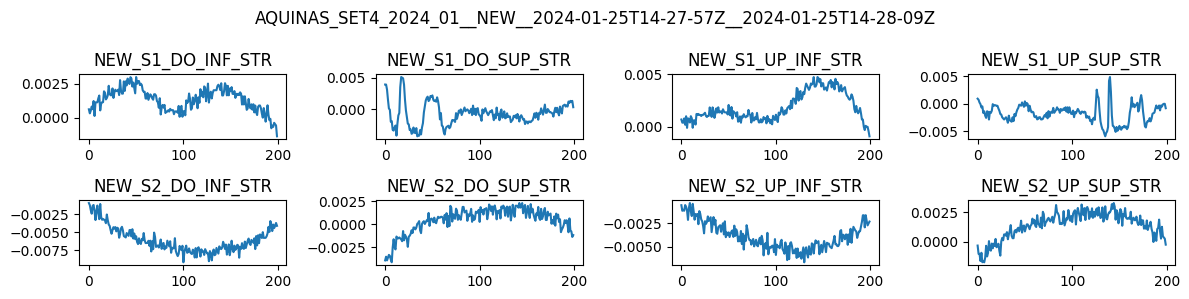

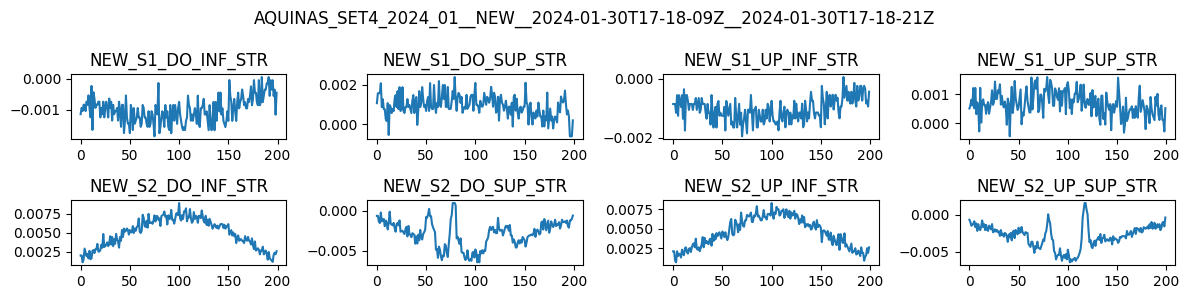

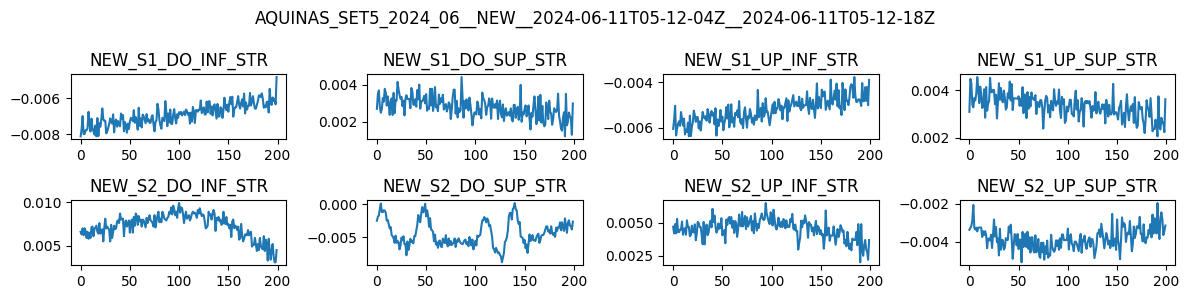

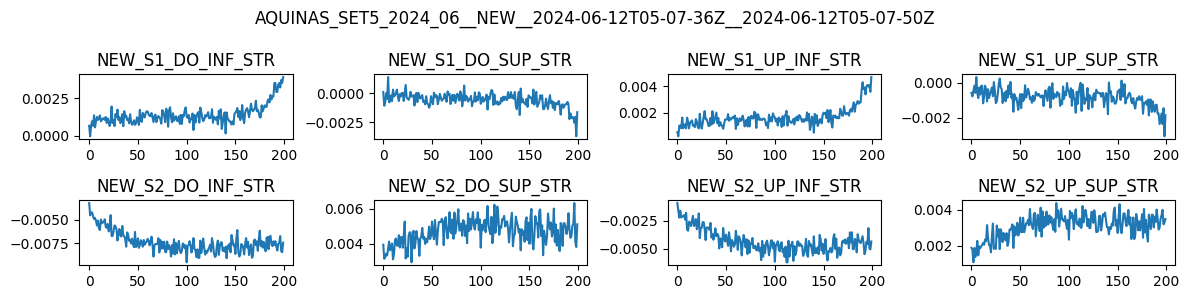

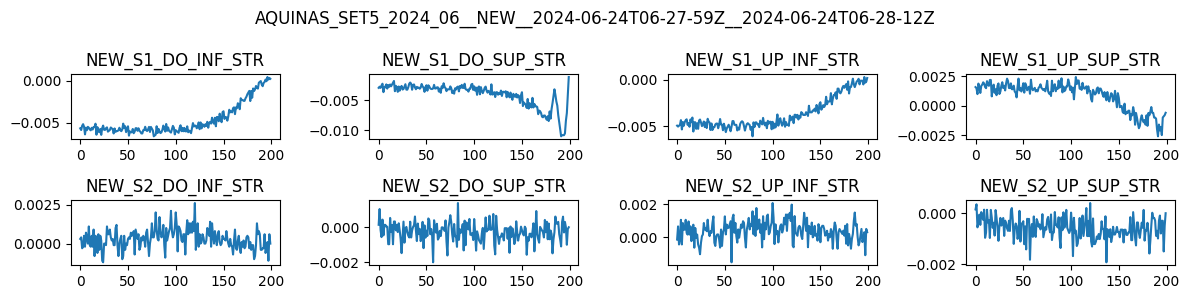

In [113]:
#Wanting to look at all the std < 1e-3 values to see what has happened. The strain gauges should be the peaks, i.e. there should be something happening

for idx, s in enumerate(strain):
    if ((s.std(axis = 0)<2e-3).all()):
        plt.figure(figsize = (12,3))
        for i in range(8):
            plt.subplot(2,4,i+1)
            plt.title(sensor_names['strain'][i])
            plt.plot(s[:,i])
        plt.suptitle(event_ids[idx])
        plt.tight_layout()
        plt.show()

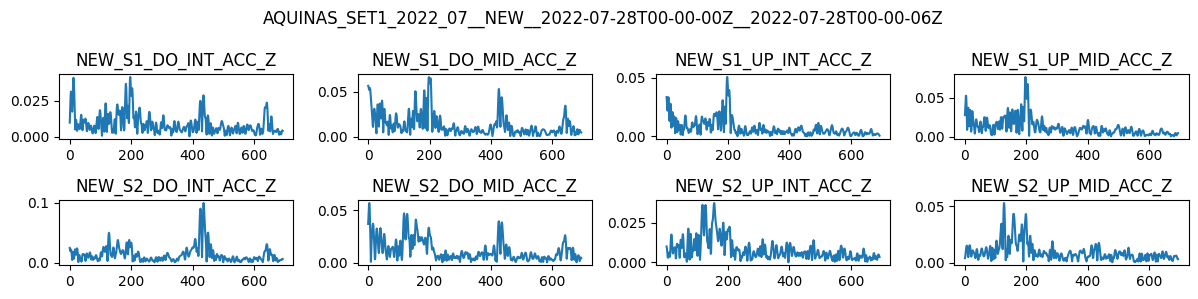

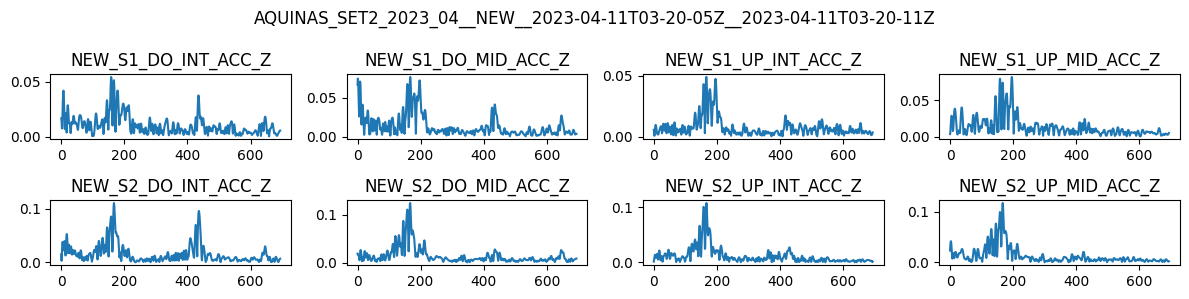

In [111]:
#Doing the same for the acceleration as well 


for idx, s in enumerate(acc):
    if ((s.std(axis = 0)<1e-2).any()):
        plt.figure(figsize = (12,3))
        for i in range(8):
            plt.subplot(2,4,i+1)
            plt.title(sensor_names['acc_z'][i])
            plt.plot(s[:,i])
        plt.suptitle(event_ids[idx])
        plt.tight_layout()
        plt.show()


#Looks ok tbh

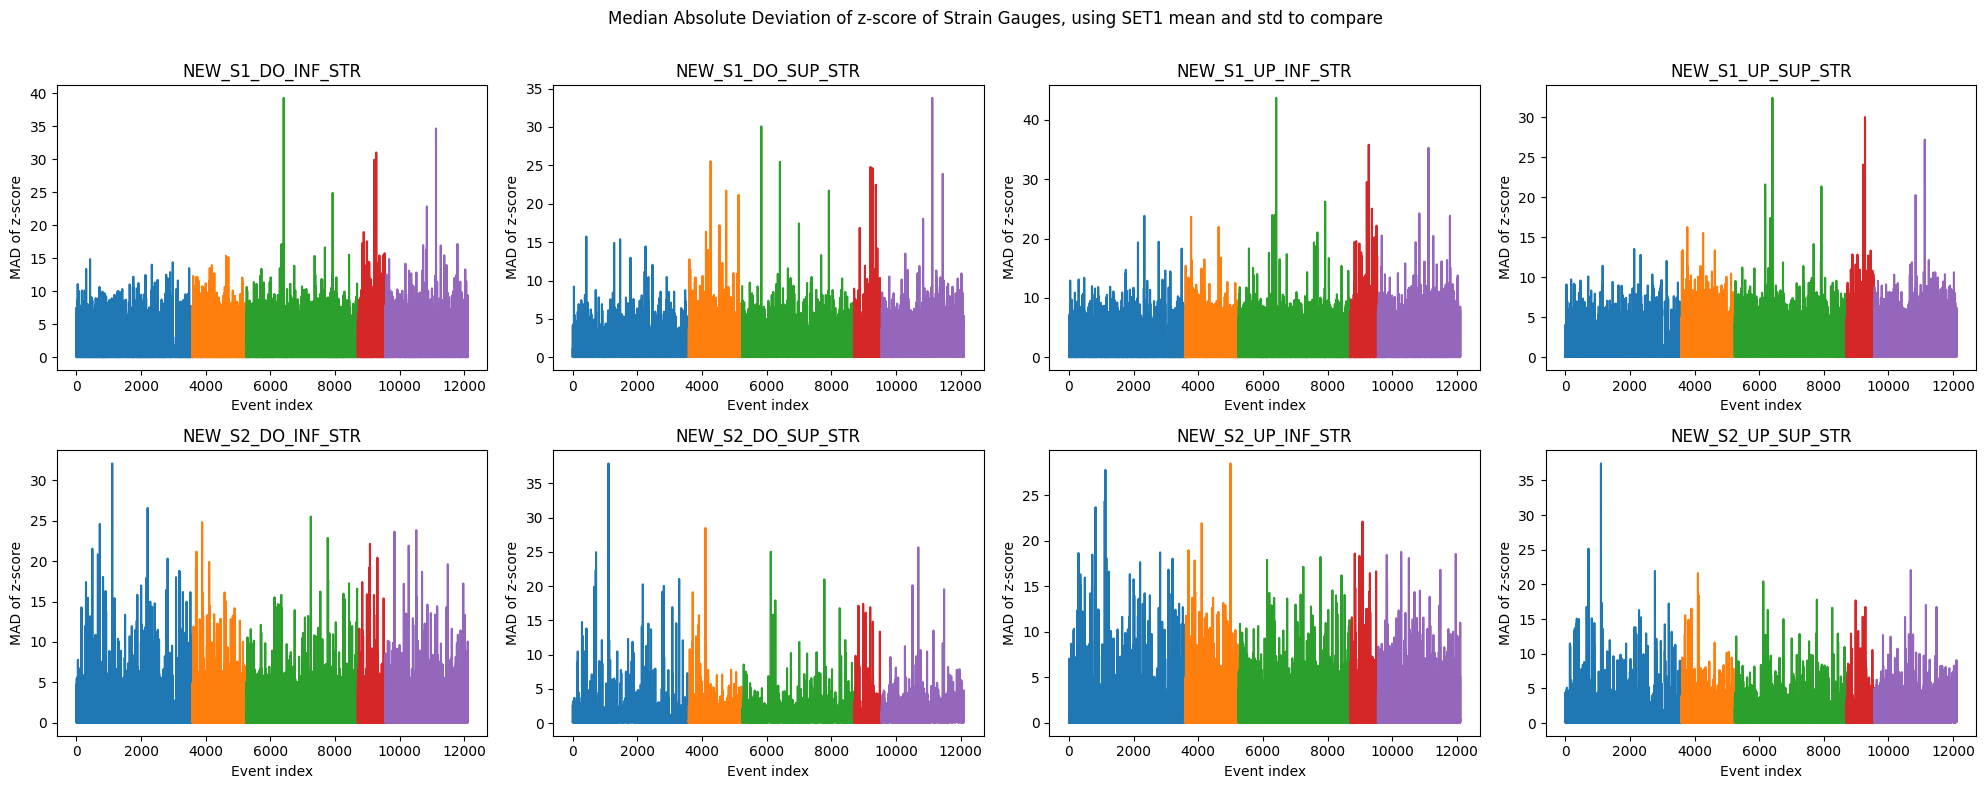

In [122]:
##MAD of SGs

mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(strain[mask],axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,8))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.median(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(2,4,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i]**2)
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Median Absolute Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


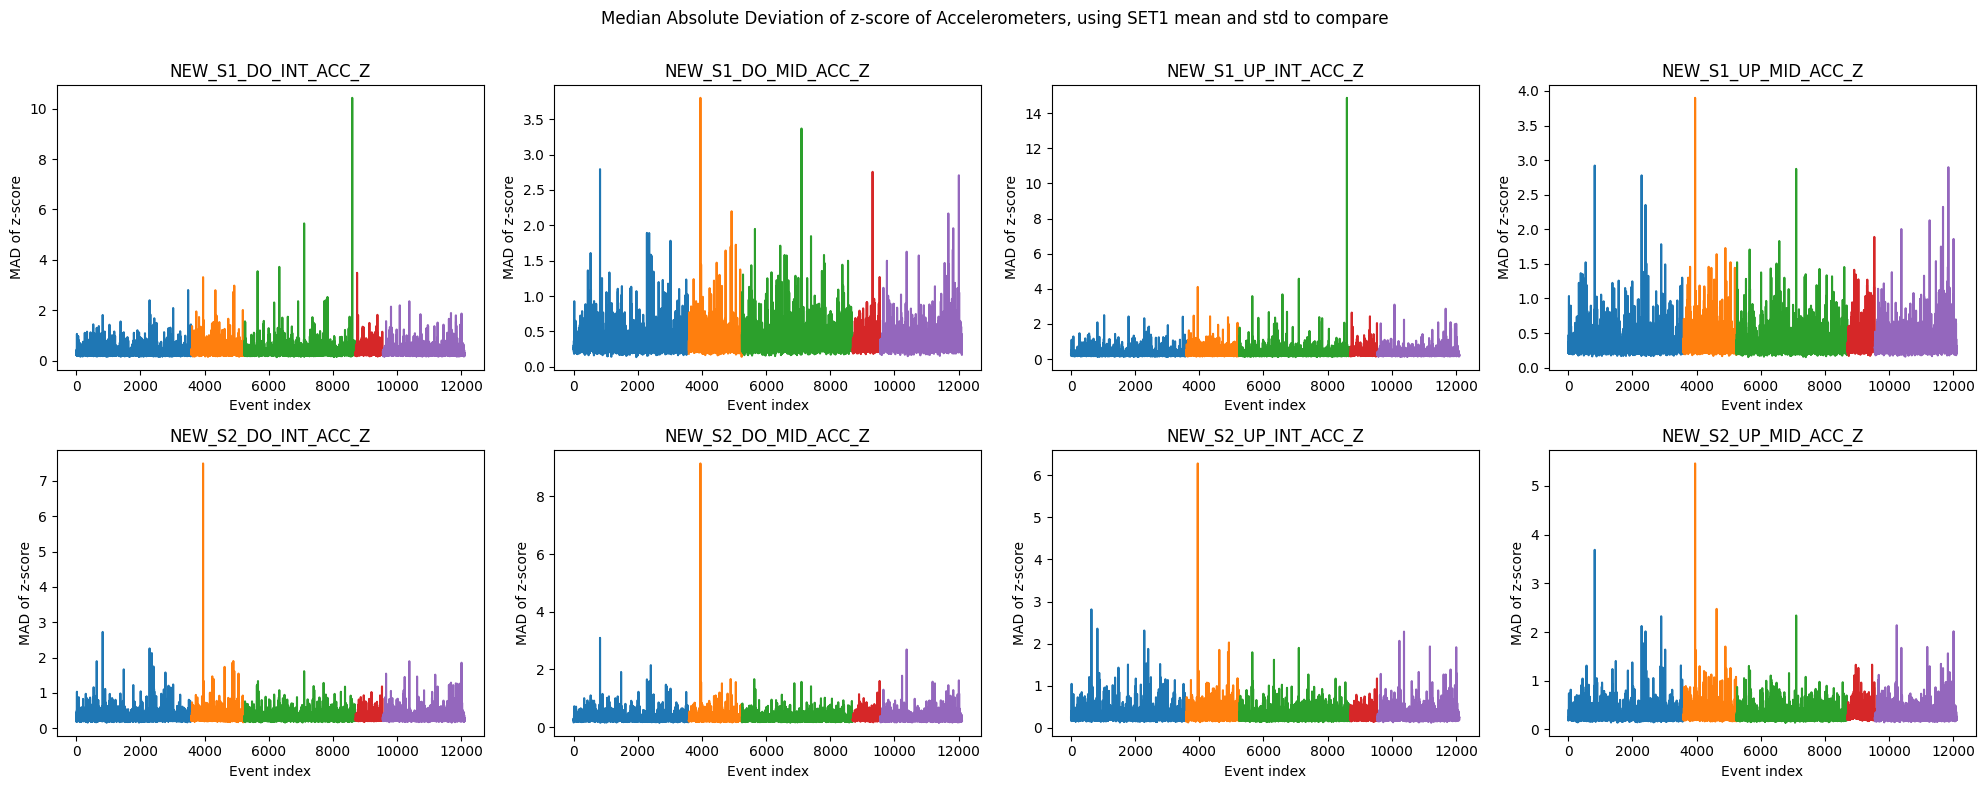

In [124]:
##MAD of accelerometers

mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(acc[mask],axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,8))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.median(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(2,4,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i]**2)
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Median Absolute Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


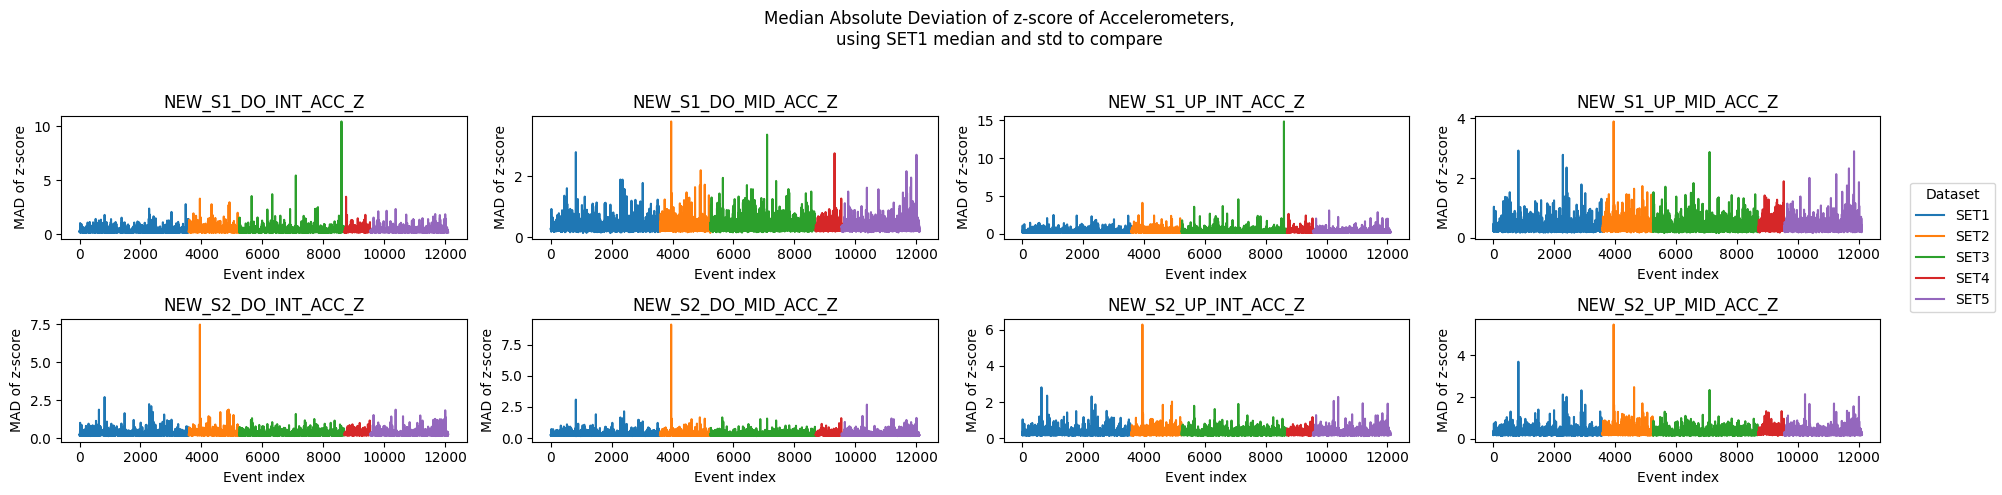

In [138]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(acc[mask], axis=0)
sigma = acc[mask].std(axis=0)

sets = [
    'AQUINAS_SET1',
    'AQUINAS_SET2',
    'AQUINAS_SET3',
    'AQUINAS_SET4',
    'AQUINAS_SET5'
]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axs = plt.subplots(2, 4, figsize=(20, 5))

idx = 0

for color, set_name in zip(colors, sets):

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma
    set_mad = np.median(np.abs(set_z), axis=1)

    label = set_name.replace('AQUINAS_', '')  # SET1, SET2, ...

    for i in range(set_mad.shape[1]):

        ax = axs.flat[i]

        ax.plot(
            np.arange(idx, len(set_mad) + idx),
            set_mad[:, i]**2,
            color=color,
            label=label if i == 0 else None  # only first subplot gets labels
        )

        ax.set_title(sensor_names['acc_z'][i])
        ax.set_ylabel('MAD of z-score')
        ax.set_xlabel('Event index')

    idx += len(set_mad)

# Get legend entries from first subplot
handles, labels = axs.flat[0].get_legend_handles_labels()

# One legend for the whole figure
fig.legend(handles, labels, loc='center right', title='Dataset')

fig.suptitle(
    'Median Absolute Deviation of z-score of Accelerometers,\n'
    'using SET1 median and std to compare'
)

# Leave space on the right for the legend
fig.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

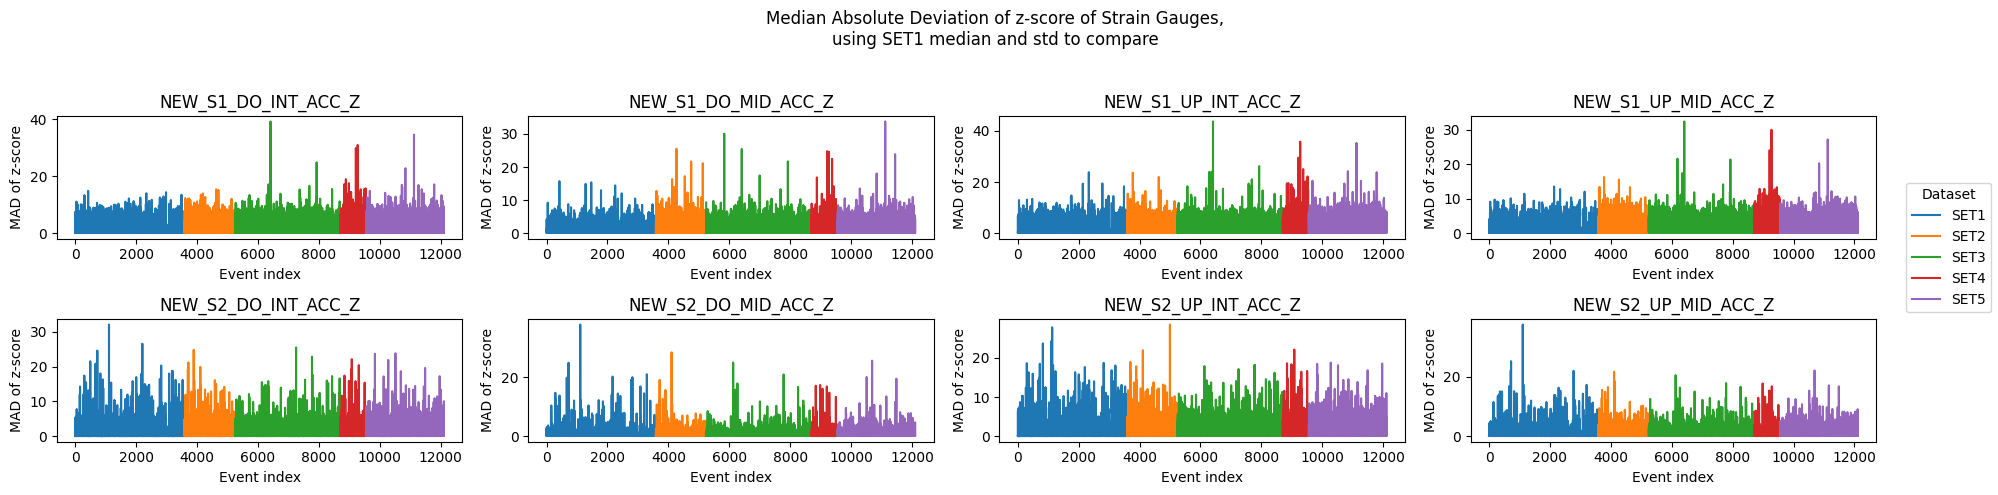

In [139]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(strain[mask], axis=0)
sigma = strain[mask].std(axis=0)

sets = [
    'AQUINAS_SET1',
    'AQUINAS_SET2',
    'AQUINAS_SET3',
    'AQUINAS_SET4',
    'AQUINAS_SET5'
]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axs = plt.subplots(2, 4, figsize=(20,5))

idx = 0

for color, set_name in zip(colors, sets):

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma
    set_mad = np.median(np.abs(set_z), axis=1)

    label = set_name.replace('AQUINAS_', '')  # SET1, SET2, ...

    for i in range(set_mad.shape[1]):

        ax = axs.flat[i]

        ax.plot(
            np.arange(idx, len(set_mad) + idx),
            set_mad[:, i]**2,
            color=color,
            label=label if i == 0 else None  # only first subplot gets labels
        )

        ax.set_title(sensor_names['acc_z'][i])
        ax.set_ylabel('MAD of z-score')
        ax.set_xlabel('Event index')

    idx += len(set_mad)

# Get legend entries from first subplot
handles, labels = axs.flat[0].get_legend_handles_labels()

# One legend for the whole figure
fig.legend(handles, labels, loc='center right', title='Dataset')

fig.suptitle(
    'Median Absolute Deviation of z-score of Strain Gauges,\n'
    'using SET1 median and std to compare'
)

# Leave space on the right for the legend
fig.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

In [ ]:
thresholds = (np.quantile(set_mad,0.99, axis = 0))


anom_bool = (set_mad >= thresholds)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True,  True],
       [False, False, False, ..., False, False, False]])

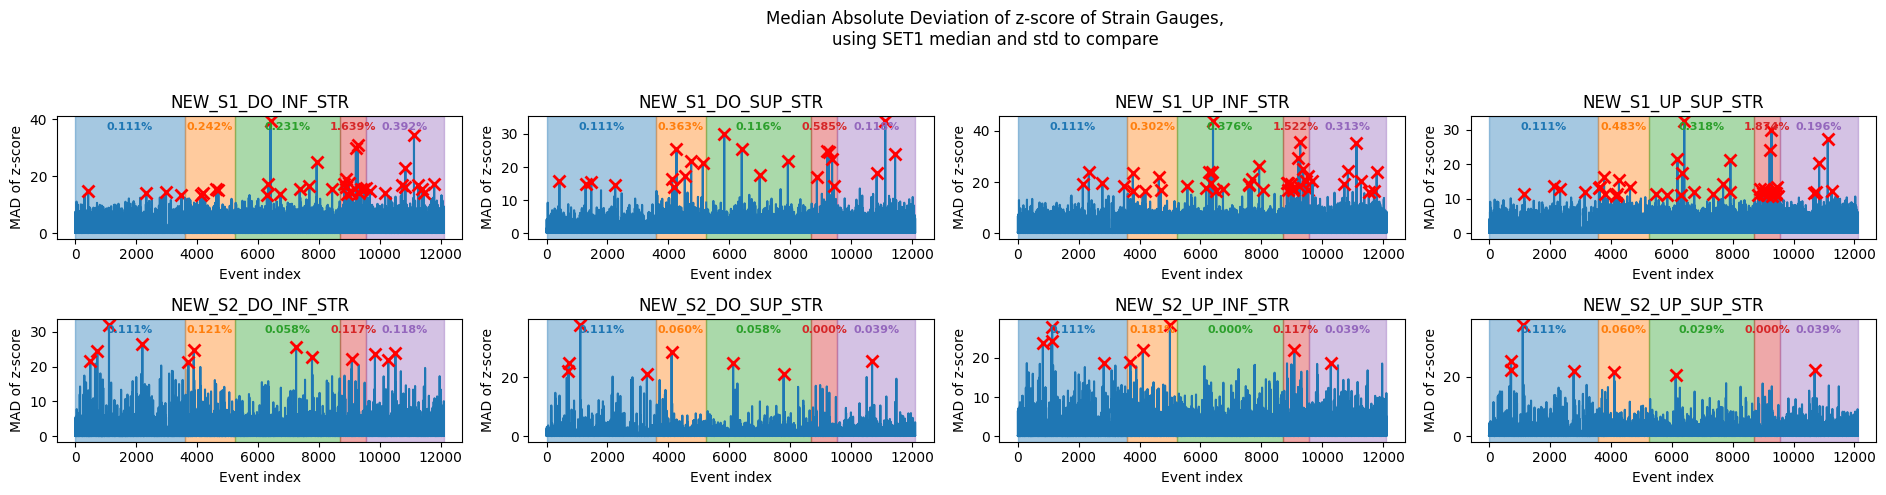

In [164]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(strain[mask], axis=0)
sigma = strain[mask].std(axis=0)

sets = [
    'AQUINAS_SET1',
    'AQUINAS_SET2',
    'AQUINAS_SET3',
    'AQUINAS_SET4',
    'AQUINAS_SET5'
]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axs = plt.subplots(2, 4, figsize=(20,5))

idx = 0

for color, set_name in zip(colors, sets):

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma
    set_mad = np.median(np.abs(set_z), axis=1)

    if color == 'C0':
        thresholds = (np.quantile(set_mad,0.999, axis = 0))

    #now checking anomalies

    anom_bool = (set_mad > thresholds)


    label = set_name.replace('AQUINAS_', '')  # SET1, SET2, ...

    for i in range(set_mad.shape[1]):
        x = np.arange(idx, len(set_mad) + idx)
        y = set_mad[:, i]**2

        ax = axs.flat[i]

        ax.axvspan(
        idx,
        idx + len(set_mad) - 1,
        color=color,
        alpha=0.4
    )

        ax.plot(
            x,
            y,
            color='tab:blue',
            label=label if i == 0 else None  # only first subplot gets labels
        )

        ax.plot(
            x[anom_bool[:, i]],
            y[anom_bool[:, i]],
            'rx',
            markersize=8,
            markeredgewidth=2
        )

        pct = 100 * np.mean(anom_bool[:, i])

        start = idx
        end = idx + len(set_mad) - 1

        ax.text(
            (start + end) / 2,          # center of the set region
            0.95,                       # near top of axis
            f'{pct:.3f}%',
            color=color,
            transform=ax.get_xaxis_transform(),  # x=data coords, y=axes coords
            ha='center',
            va='top',
            fontsize=8,
            fontweight='bold'
        )

        ax.set_title(sensor_names['strain'][i])
        ax.set_ylabel('MAD of z-score')
        ax.set_xlabel('Event index')

    idx += len(set_mad)

# Get legend entries from first subplot
handles, labels = axs.flat[0].get_legend_handles_labels()

# One legend for the whole figure
#fig.legend(handles, labels, loc='center right', title='Dataset')

fig.suptitle(
    'Median Absolute Deviation of z-score of Strain Gauges,\n'
    'using SET1 median and std to compare'
)

# Leave space on the right for the legend
fig.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

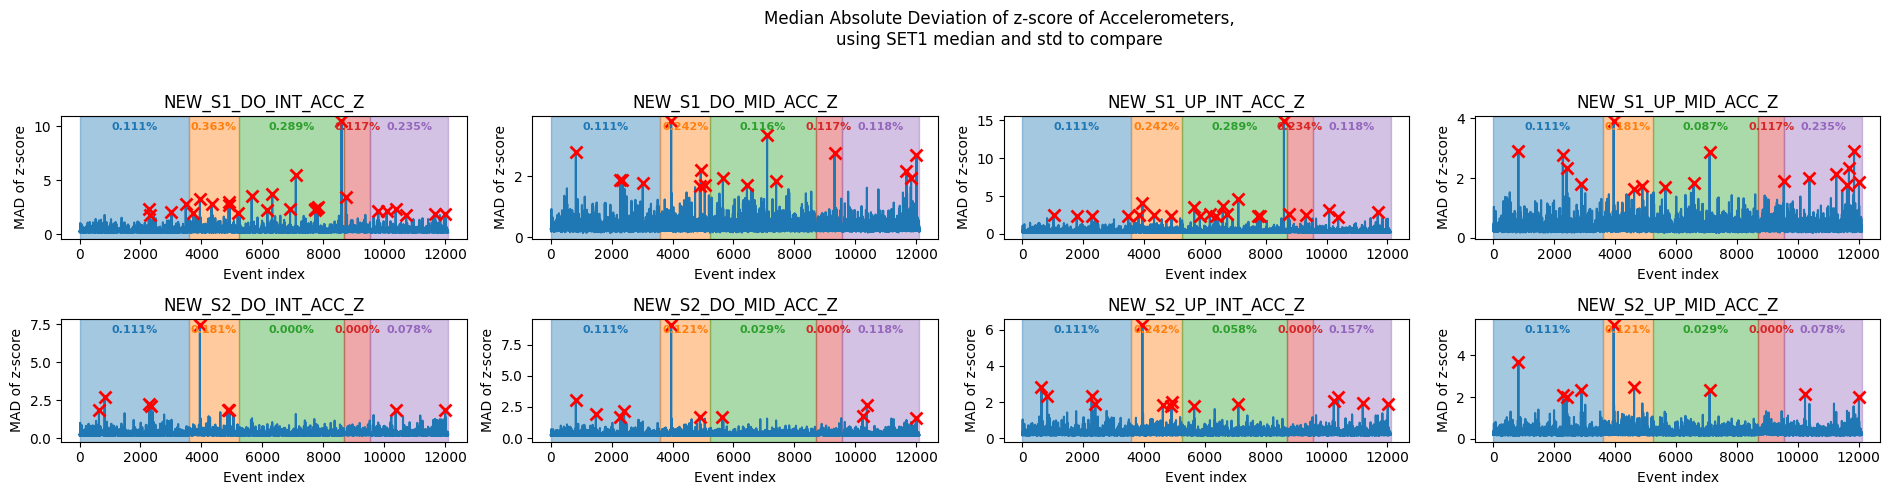

In [163]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(acc[mask], axis=0)
sigma = acc[mask].std(axis=0)

sets = [
    'AQUINAS_SET1',
    'AQUINAS_SET2',
    'AQUINAS_SET3',
    'AQUINAS_SET4',
    'AQUINAS_SET5'
]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axs = plt.subplots(2, 4, figsize=(20,5))

idx = 0

for color, set_name in zip(colors, sets):

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma
    set_mad = np.median(np.abs(set_z), axis=1)

    if color == 'C0':
        thresholds = (np.quantile(set_mad,0.999, axis = 0))

    #now checking anomalies

    anom_bool = (set_mad > thresholds)


    label = set_name.replace('AQUINAS_', '')  # SET1, SET2, ...

    for i in range(set_mad.shape[1]):
        x = np.arange(idx, len(set_mad) + idx)
        y = set_mad[:, i]**2

        ax = axs.flat[i]

        ax.axvspan(
        idx,
        idx + len(set_mad) - 1,
        color=color,
        alpha=0.4
    )

        ax.plot(
            x,
            y,
            color='tab:blue',
            label=label if i == 0 else None  # only first subplot gets labels
        )

        ax.plot(
            x[anom_bool[:, i]],
            y[anom_bool[:, i]],
            'rx',
            markersize=8,
            markeredgewidth=2
        )

        pct = 100 * np.mean(anom_bool[:, i])

        start = idx
        end = idx + len(set_mad) - 1

        ax.text(
            (start + end) / 2,          # center of the set region
            0.95,                       # near top of axis
            f'{pct:.3f}%',
            color=color,
            transform=ax.get_xaxis_transform(),  # x=data coords, y=axes coords
            ha='center',
            va='top',
            fontsize=8,
            fontweight='bold'
        )

        ax.set_title(sensor_names['acc_z'][i])
        ax.set_ylabel('MAD of z-score')
        ax.set_xlabel('Event index')

    idx += len(set_mad)

# Get legend entries from first subplot
handles, labels = axs.flat[0].get_legend_handles_labels()

# One legend for the whole figure
#fig.legend(handles, labels, loc='center right', title='Dataset')

fig.suptitle(
    'Median Absolute Deviation of z-score of Accelerometers,\n'
    'using SET1 median and std to compare'
)

# Leave space on the right for the legend
fig.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

### Evaluating Strain Gauges using different methods

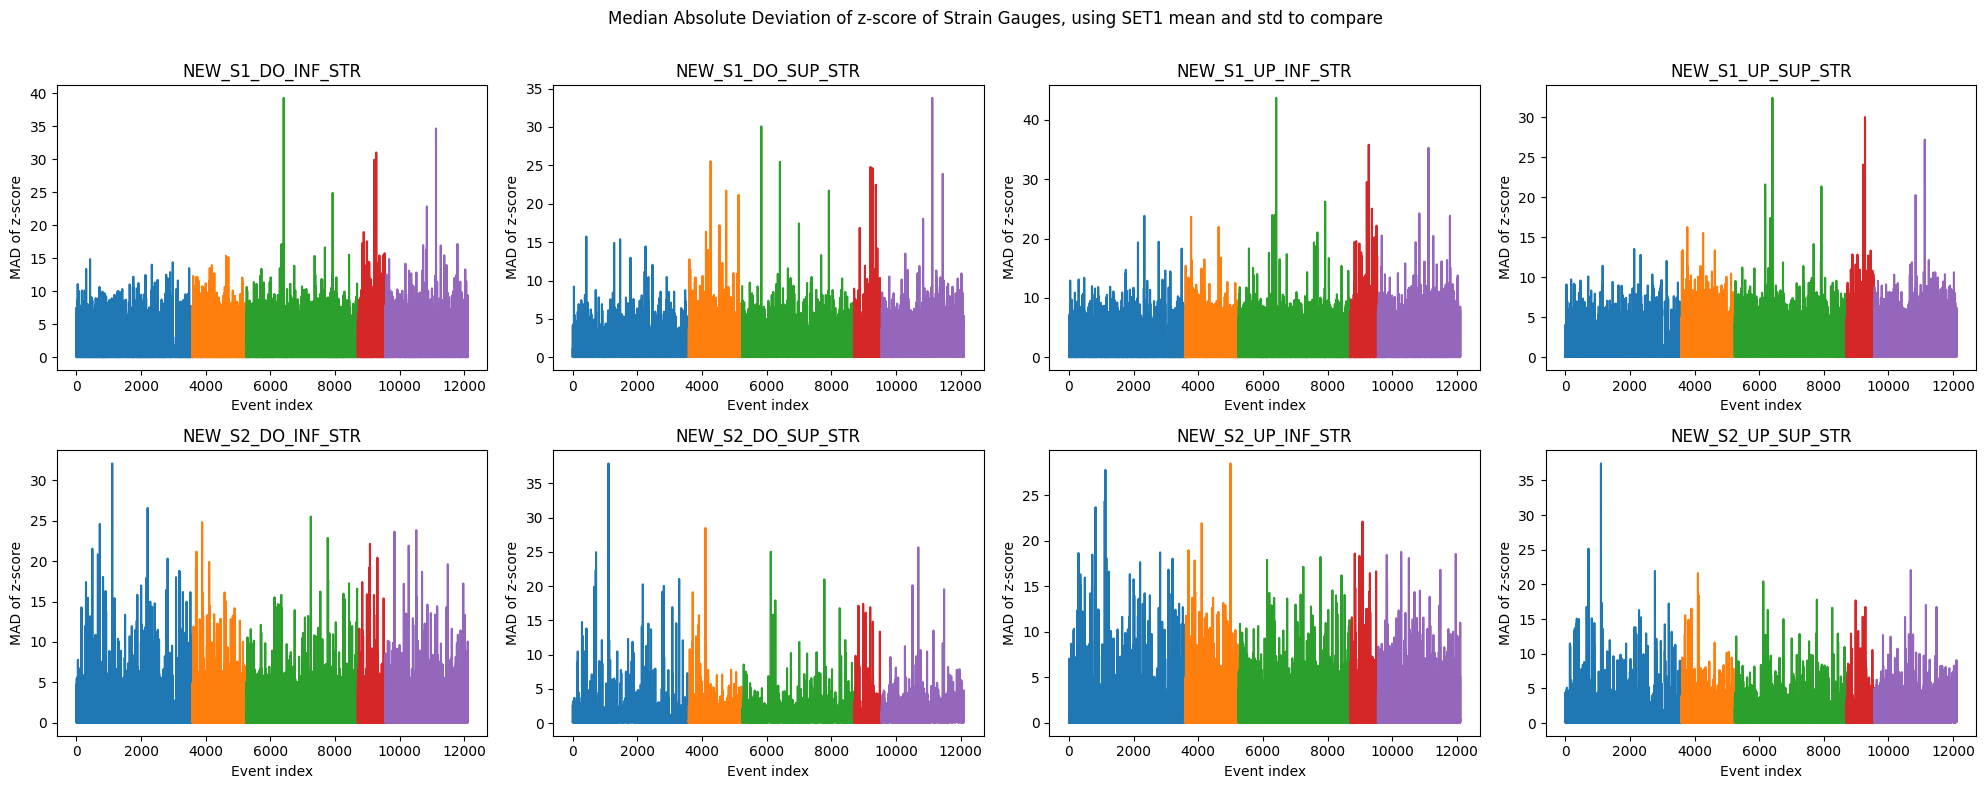

In [121]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = np.median(strain[mask],axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,8))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.median(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(2,4,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i]**2)
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Median Absolute Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


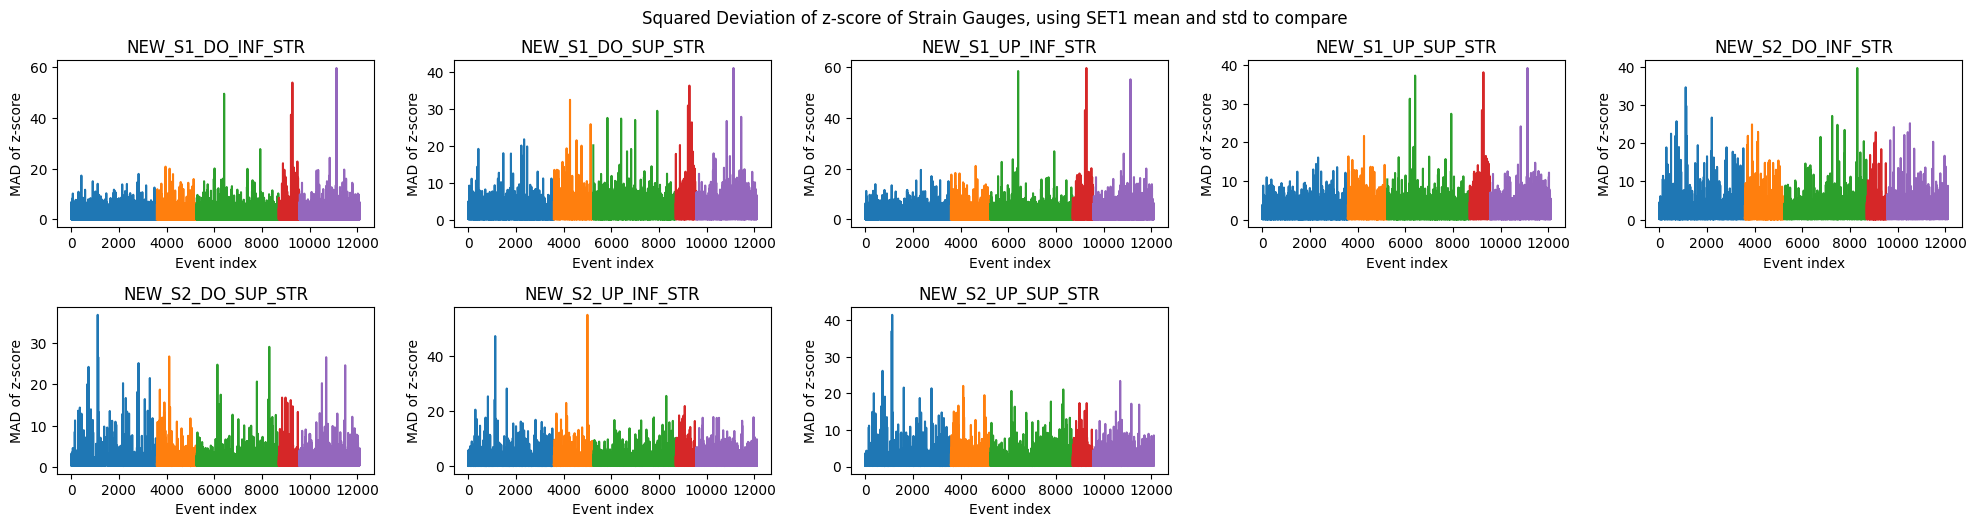

In [15]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = strain[mask].mean(axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.mean((set_z)**2, axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Squared Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


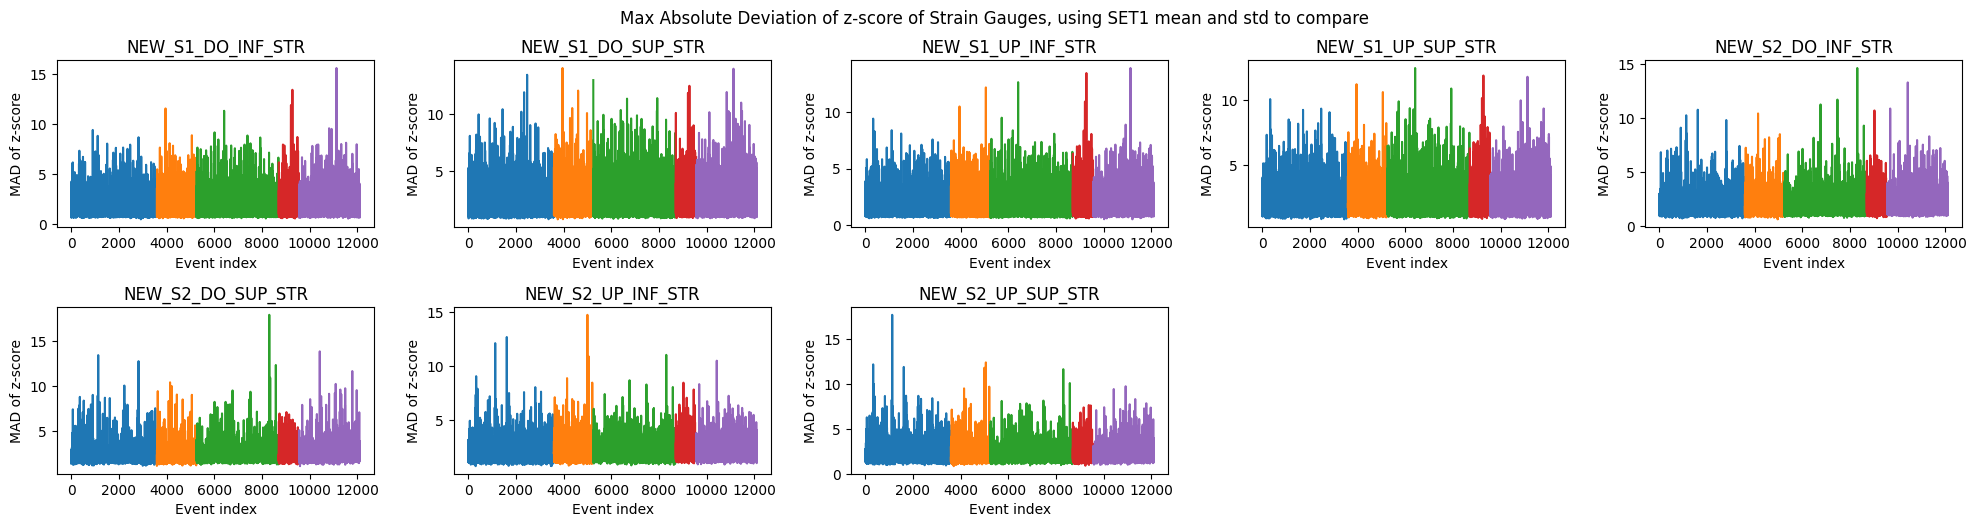

In [16]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = strain[mask].mean(axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.max(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Max Absolute Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


In [17]:
from sklearn.ensemble import IsolationForest

In [18]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

isos = [IsolationForest() for i in range(40)]

[isos[i].fit(strain[mask][:,:,i]) for i in range(40)]


plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    #This one gives a score-per-event from IsolationForest
    set_mad = [isos[i].decision_function(strain[set_mask][:,:,i]) for i in range(40)]

    for i in range(40):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad[i])+idx),set_mad[i],',')
        plt.title(sensor_names['strain'][i])
        plt.ylabel('Score from IsolationForest\n(higher = better)')
        plt.xlabel('Event index')

    idx += len(set_mad[i])


plt.suptitle('IsolationForecast Strain Gauges, using SET1 to fit\n')
plt.tight_layout()
plt.show()

IndexError: index 8 is out of bounds for axis 2 with size 8

### Evaluating accelerometers using different methods

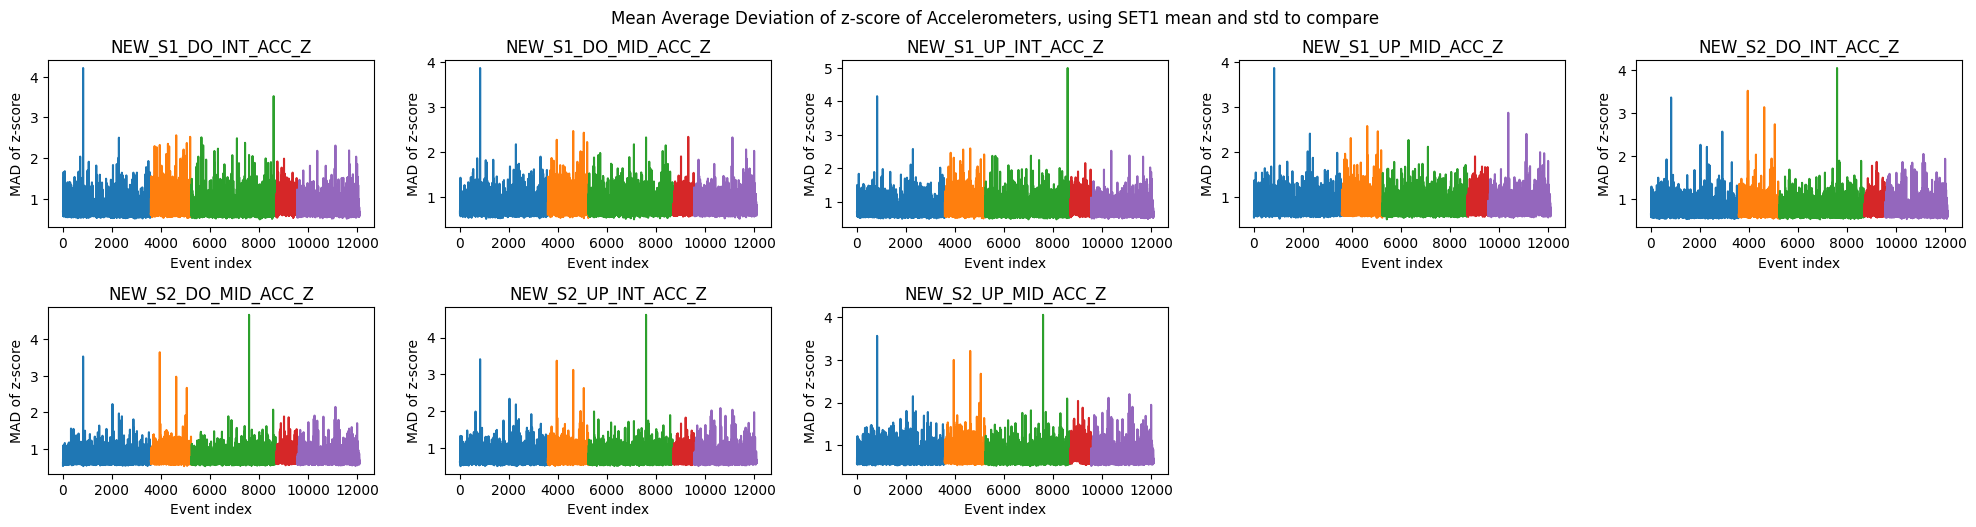

In [19]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.mean(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Mean Average Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


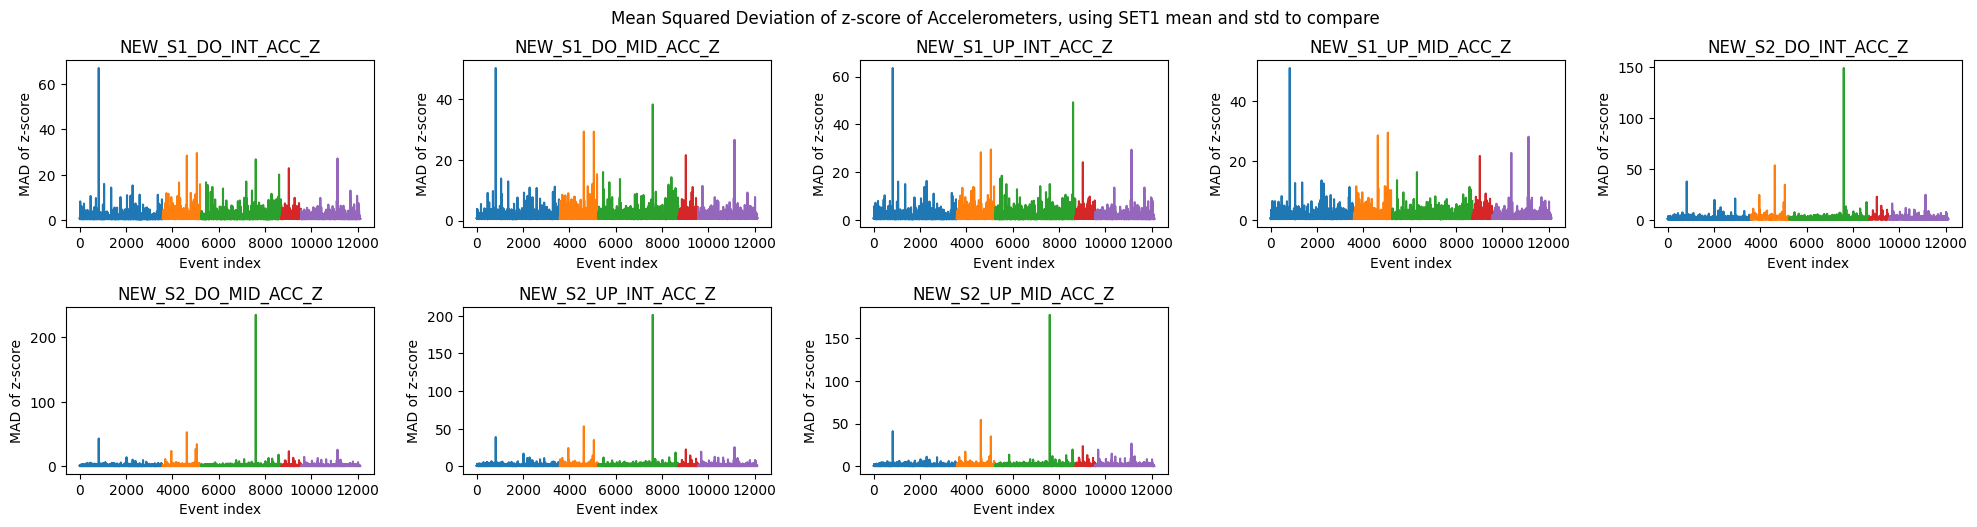

In [20]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.mean((set_z)**2, axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Mean Squared Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()





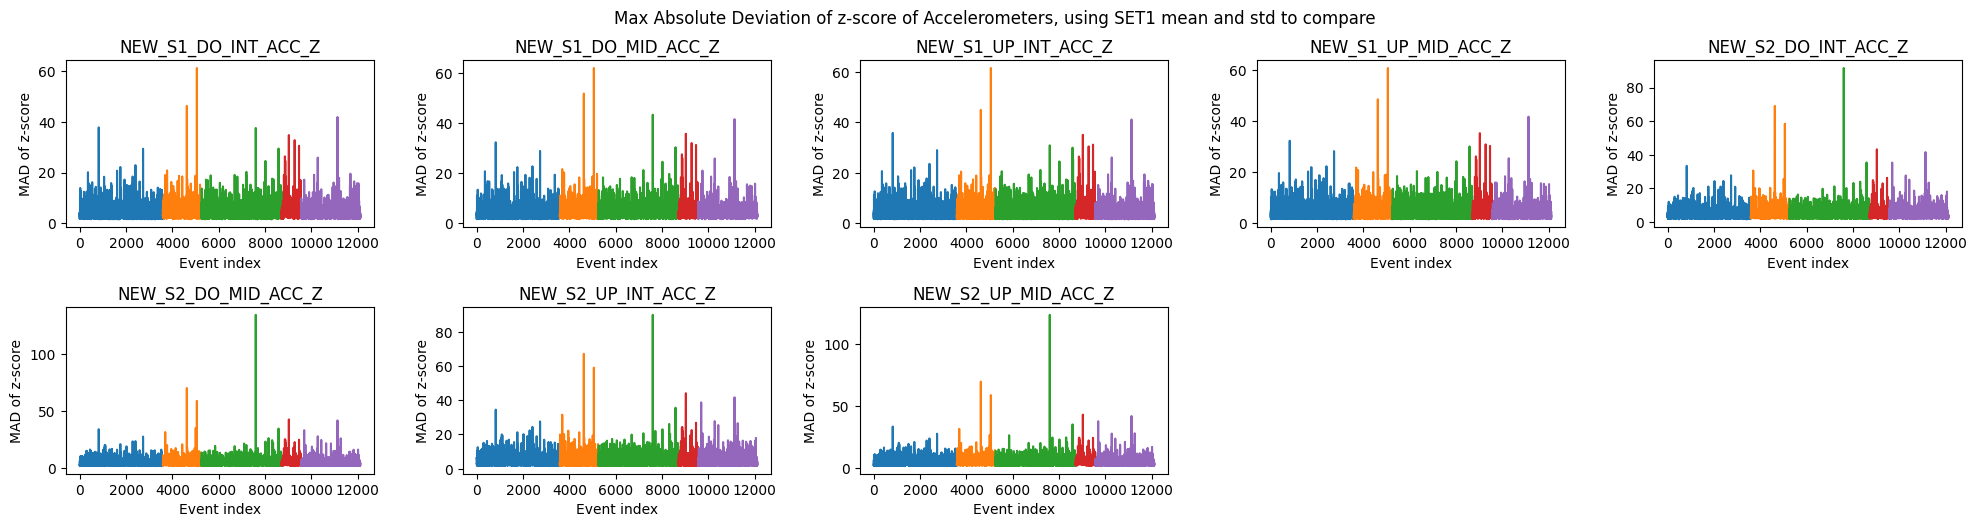

In [21]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.max(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Max Absolute Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()





In [22]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

isos = [IsolationForest() for i in range(40)]

[isos[i].fit(acc[mask][:,:,i]) for i in range(40)]


plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    #This one gives a score-per-event from IsolationForest
    set_mad = [isos[i].decision_function(acc[set_mask][:,:,i]) for i in range(40)]

    for i in range(40):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad[i])+idx),set_mad[i],',')
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('Score from IsolationForest\n(higher = better)')
        plt.xlabel('Event index')

    idx += len(set_mad[i])


plt.suptitle('IsolationForest Accelerometers, using SET1 to fit\n')
plt.tight_layout()
plt.show()

IndexError: index 8 is out of bounds for axis 2 with size 8